# Lyria Time Signature Analysis (v1 vs v2)

Compare `results.csv` (v1) and `results_v2.csv` (v2) on Lyria outputs, using `human_ear_time_sig` as truth when available.


In [26]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact

sns.set_theme(style="whitegrid")
TIME_SIGS = ["2/4", "3/4", "4/4", "5/4", "6/8", "7/8"]
os.makedirs("figures", exist_ok=True)


In [30]:
# Load two Lyria result files
sources = [
    ("v1", "/Users/mac/Desktop/DATA35900/final_project/DATA359-final-project/audio/Lyria/results.csv"),
    ("v2", "/Users/mac/Desktop/DATA35900/final_project/DATA359-final-project/audio/Suno/results.csv"),
]

dfs = []
for method, csv_path in sources:
    if not os.path.exists(csv_path):
        print(f"[missing] {csv_path}")
        continue
    df = pd.read_csv(csv_path)
    df["method"] = method

    # Standardize expected columns
    if "human_ear_time_sig" not in df.columns:
        df["human_ear_time_sig"] = pd.NA
    if "prompt_type" not in df.columns:
        df["prompt_type"] = pd.NA
    if "tempo" not in df.columns:
        df["tempo"] = np.nan
    if "confidence" not in df.columns:
        df["confidence"] = np.nan

    # Human ear as truth when available; otherwise fallback to desired vs actual
    has_human = df["human_ear_time_sig"].notna()
    human = df["human_ear_time_sig"].astype(str).str.strip()
    desired = df["desired_time_sig"].astype(str).str.strip()
    actual = df["actual_time_sig"].astype(str).str.strip()

    df["truth_time_sig"] = np.where(has_human, human, desired)
    df["correct_eval"] = np.where(has_human, (human == desired), (actual == desired)).astype(float)

    dfs.append(df)

if not dfs:
    raise ValueError("No Lyria results found. Expected audio/Lyria/results.csv and/or results_v2.csv")

data = pd.concat(dfs, ignore_index=True)
print("loaded methods:", data["method"].unique().tolist())
print(data.groupby("method").size())
display(data.head())


loaded methods: ['v1', 'v2']
method
v1    250
v2    250
dtype: int64


,filename,model,human_ear_time_sig,desired_time_sig,actual_time_sig,correct,prompt_type,prompt_num,run,tempo,confidence,method,truth_time_sig,correct_eval
0,2_4_cultural_1_1.wav,Lyria,2/4,2/4,4/4,False,cultural,1,1,120.0,0.6056,v1,2/4,1.0
1,2_4_cultural_1_2.wav,Lyria,2/4,2/4,4/4,False,cultural,1,2,120.0,0.6627,v1,2/4,1.0
2,2_4_cultural_1_3.wav,Lyria,2/4,2/4,4/4,False,cultural,1,3,120.0,0.4721,v1,2/4,1.0
3,2_4_cultural_1_4.wav,Lyria,2/4,2/4,4/4,False,cultural,1,4,120.0,0.4899,v1,2/4,1.0
4,2_4_cultural_1_5.wav,Lyria,2/4,2/4,4/4,False,cultural,1,5,120.0,0.3911,v1,2/4,1.0


## Overall Accuracy Comparison


In [31]:
summary = (
    data.groupby(["method", "model"])['correct_eval']
    .agg(correct='sum', total='count', accuracy='mean')
    .round(3)
)
display(summary)

acc_table = (
    data.groupby(["method", "desired_time_sig"])['correct_eval']
    .mean()
    .unstack("desired_time_sig")
    .reindex(columns=TIME_SIGS)
    .round(3)
)
display(acc_table)


,,correct,total,accuracy
method,model,,,
v1,Lyria,128.0,250,0.512
v2,Suno,82.0,250,0.328


desired_time_sig,2/4,3/4,4/4,5/4,6/8,7/8
method,,,,,,
v1,1.0,0.46,1.0,0.0,0.10,NaN
v2,0.0,0.50,1.0,0.0,0.14,NaN


## Confusion Matrix (Desired vs Truth) by Method


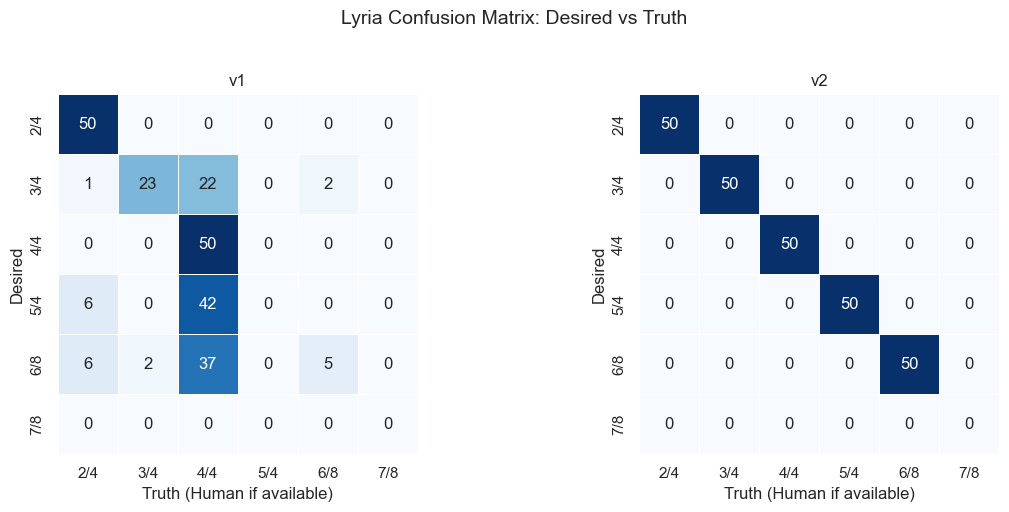

In [33]:
methods = data['method'].dropna().unique().tolist()
fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 5))
if len(methods) == 1:
    axes = [axes]

for ax, m in zip(axes, methods):
    df_m = data[data['method'] == m]
    cm = (
        pd.crosstab(df_m['desired_time_sig'], df_m['truth_time_sig'])
        .reindex(index=TIME_SIGS, columns=TIME_SIGS, fill_value=0)
    )
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.5, cbar=False, square=True)
    ax.set_title(m)
    ax.set_xlabel('Truth (Human if available)')
    ax.set_ylabel('Desired')

plt.suptitle('Lyria Confusion Matrix: Desired vs Truth', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/lyria_confusion_v1_v2.png', dpi=150, bbox_inches='tight')
plt.show()


## RQ1: Accuracy by Prompt Type (v1 vs v2)


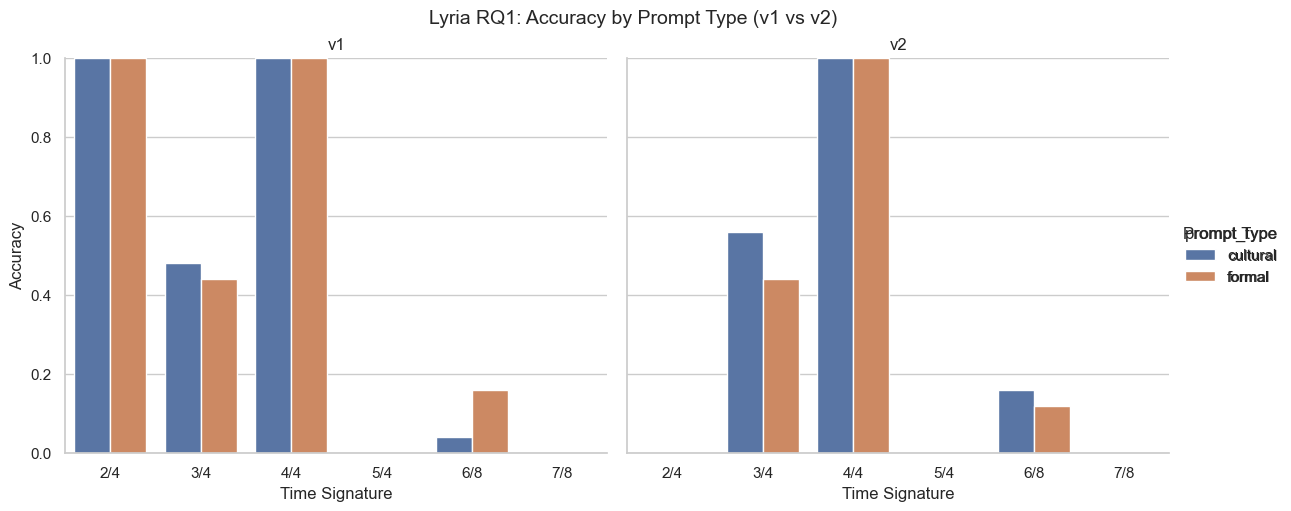

method  prompt_type
v1      cultural       0.504
        formal         0.520
v2      cultural       0.344
        formal         0.312


In [34]:
acc_by_type = (
    data.groupby(['method', 'desired_time_sig', 'prompt_type'])['correct_eval']
    .mean()
    .reset_index()
)

g = sns.catplot(
    data=acc_by_type,
    x='desired_time_sig', y='correct_eval', hue='prompt_type',
    col='method', kind='bar',
    palette={'cultural': '#4C72B0', 'formal': '#DD8452'},
    height=5, aspect=1.1, order=TIME_SIGS,
)
g.set_axis_labels('Time Signature', 'Accuracy')
g.set_titles('{col_name}')
g.add_legend(title='Prompt Type')
g.set(ylim=(0, 1))
plt.suptitle('Lyria RQ1: Accuracy by Prompt Type (v1 vs v2)', y=1.02, fontsize=14)
plt.savefig('figures/lyria_rq1_prompt_type_v1_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print(data.groupby(['method', 'prompt_type'])['correct_eval'].mean().round(3).to_string())


## RQ2: Collapse to 4/4 (by Truth)


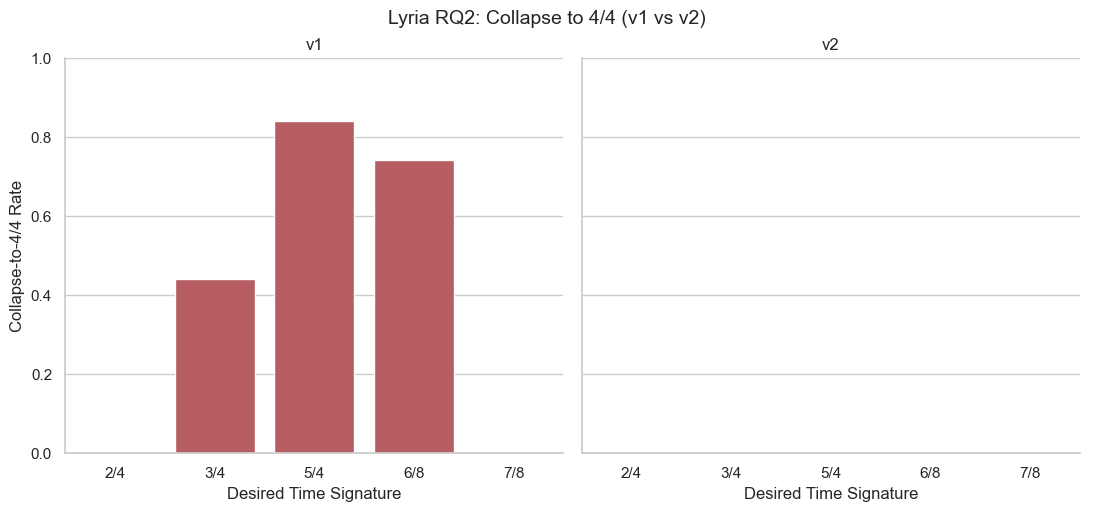

method desired_time_sig  collapsed_to_44
    v1              2/4             0.00
    v1              3/4             0.44
    v1              5/4             0.84
    v1              6/8             0.74
    v2              2/4             0.00
    v2              3/4             0.00
    v2              5/4             0.00
    v2              6/8             0.00


In [25]:
non_44 = data[data['desired_time_sig'] != '4/4'].copy()
non_44['collapsed_to_44'] = non_44['truth_time_sig'].astype(str).str.strip() == '4/4'

collapse_rate = (
    non_44.groupby(['method', 'desired_time_sig'])['collapsed_to_44']
    .mean()
    .reset_index()
)

g = sns.catplot(
    data=collapse_rate,
    x='desired_time_sig', y='collapsed_to_44',
    col='method', kind='bar',
    color='#c44e52',
    height=5, aspect=1.1,
    order=[s for s in TIME_SIGS if s != '4/4'],
)
g.set_axis_labels('Desired Time Signature', 'Collapse-to-4/4 Rate')
g.set_titles('{col_name}')
g.set(ylim=(0, 1))
plt.suptitle('Lyria RQ2: Collapse to 4/4 (v1 vs v2)', y=1.02, fontsize=14)
plt.savefig('figures/lyria_rq2_collapse_v1_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print(collapse_rate.to_string(index=False))


## Statistical Test: RQ1 by Method


In [ ]:
for m in data['method'].unique():
    df_m = data[data['method'] == m]
    ct = (
        pd.crosstab(df_m['prompt_type'], df_m['correct_eval'])
        .reindex(index=['cultural', 'formal'], columns=[0.0, 1.0], fill_value=0)
    )
    _, p = fisher_exact(ct.values)

    c_acc = df_m[df_m['prompt_type'] == 'cultural']['correct_eval'].mean()
    f_acc = df_m[df_m['prompt_type'] == 'formal']['correct_eval'].mean()

    sig = '* significant' if p < 0.05 else 'not significant'
    print(f"{m}:")
    print(f"  cultural accuracy : {c_acc:.3f}")
    print(f"  formal accuracy   : {f_acc:.3f}")
    print(f"  difference        : {c_acc - f_acc:+.3f}")
    print(f"  p-value           : {p:.4f}  ({sig})")
    print()


## Tempo Distribution by Method


In [ ]:
methods = data['method'].unique()
fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 5))
if len(methods) == 1:
    axes = [axes]

for ax, m in zip(axes, methods):
    df_m = data[data['method'] == m]
    groups = [df_m[df_m['desired_time_sig'] == ts]['tempo'].dropna() for ts in TIME_SIGS]
    ax.boxplot(groups, labels=TIME_SIGS, patch_artist=True, boxprops=dict(facecolor='#a8c8e8'))
    ax.set_title(m)
    ax.set_xlabel('Desired Time Signature')
    ax.set_ylabel('Detected Tempo (BPM)')

plt.suptitle('Lyria Tempo Distribution by Desired Time Signature (v1 vs v2)', fontsize=14)
plt.tight_layout()
plt.savefig('figures/lyria_tempo_v1_v2.png', dpi=150, bbox_inches='tight')
plt.show()
